In [2]:
import pandas as pd
import networkx as nx
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_2015 = pd.read_csv("/kaggle/input/datasets/debjitbanerji/shipping-data/events_2015_full.csv")
df_2025 = pd.read_csv("/kaggle/input/datasets/debjitbanerji/shipping-data/events_2025_full.csv")

# Convert timestamps
df_2015["entry_time"] = pd.to_datetime(df_2015["entry_time"])
df_2015["exit_time"] = pd.to_datetime(df_2015["exit_time"])
df_2025["entry_time"] = pd.to_datetime(df_2025["entry_time"])
df_2025["exit_time"] = pd.to_datetime(df_2025["exit_time"])

# Sort globally (important)
df_2015 = df_2015.sort_values(["ship_id", "entry_time"])
df_2025 = df_2025.sort_values(["ship_id", "entry_time"])

MIN_TIME_GAP_HRS = 1

df_2015["gap"] = df_2015.groupby("ship_id")["entry_time"].diff().dt.total_seconds() / 3600
df_2025["gap"] = df_2025.groupby("ship_id")["entry_time"].diff().dt.total_seconds() / 3600

df_2015 = df_2015[(df_2015["gap"].isna()) | (df_2015["gap"] < 1000)]  # tune threshold
df_2025 = df_2025[(df_2025["gap"].isna()) | (df_2025["gap"] < 1000)]  # tune threshold

In [4]:
def validate_ports(df):
    print("Total rows:", len(df))
    
    missing_id = df["port_id"].isna().sum()
    missing_name = df["port_name"].isna().sum()
    
    print("Missing port_id:", missing_id)
    print("Missing port_name:", missing_name)
    
    unique_ports = df["port_id"].nunique()
    print("Unique ports:", unique_ports)

validate_ports(df_2015)
validate_ports(df_2025)

Total rows: 2211877
Missing port_id: 0
Missing port_name: 546828
Unique ports: 7138
Total rows: 2448119
Missing port_id: 0
Missing port_name: 639493
Unique ports: 7788


In [5]:
def log_binning(data, bins=30):
    data = data[data > 0]  # remove zeros
    min_x = np.min(data)
    max_x = np.max(data)

    bins = np.logspace(np.log10(min_x), np.log10(max_x), bins)
    hist, edges = np.histogram(data, bins=bins)
    centers = np.sqrt(edges[:-1] * edges[1:])  # geometric mean

    return centers, hist

def build_ship_sequences(df, remove_consecutive_duplicates=True):
    ship_paths = {}

    for ship_id, g in df.groupby("ship_id", sort=False):
        g = g.sort_values("entry_time")
        ports = g["port_id"].tolist()

        if remove_consecutive_duplicates:
            cleaned = []
            for p in ports:
                if not cleaned or cleaned[-1] != p:
                    cleaned.append(p)
            ports = cleaned

        if len(ports) >= 2:
            ship_paths[ship_id] = ports

    return ship_paths

def build_directed_weighted_graph(ship_paths):
    edge_w = defaultdict(int)

    for ship_id, ports in ship_paths.items():
        for u, v in zip(ports[:-1], ports[1:]):
            if u != v:
                edge_w[(u, v)] += 1

    G = nx.DiGraph()
    for (u, v), w in edge_w.items():
        G.add_edge(u, v, weight=w)

    return G

def build_undirected_weighted_graph(Gd):
    Gu = nx.Graph()

    for u, v, data in Gd.edges(data=True):
        w = data.get("weight", 1)

        if Gu.has_edge(u, v):
            Gu[u][v]["weight"] += w
        else:
            Gu.add_edge(u, v, weight=w)

    return Gu

def attach_port_metadata(G, df):
    meta = df.drop_duplicates("port_id")[["port_id", "port_name", "lat", "lon"]]
    for _, r in meta.iterrows():
        pid = r["port_id"]
        if pid not in G:
            G.add_node(pid)
        G.nodes[pid]["port_name"] = r["port_name"]
        G.nodes[pid]["lat"] = float(r["lat"]) if pd.notna(r["lat"]) else None
        G.nodes[pid]["lon"] = float(r["lon"]) if pd.notna(r["lon"]) else None

def graph_eda(Gd, Gu):
    print("DIRECTED GRAPH")
    print("nodes:", Gd.number_of_nodes())
    print("edges:", Gd.number_of_edges())
    print("density:", nx.density(Gd))
    print("SCCs:", nx.number_strongly_connected_components(Gd))
    print("WCCs:", nx.number_weakly_connected_components(Gd))

    print("\nUNDIRECTED GRAPH")
    print("nodes:", Gu.number_of_nodes())
    print("edges:", Gu.number_of_edges())
    print("density:", nx.density(Gu))
    print("connected components:", nx.number_connected_components(Gu))

def degree_distributions(Gd, Gu, label=""):
    out_deg = np.array([d for _, d in Gd.out_degree()])
    in_deg  = np.array([d for _, d in Gd.in_degree()])
    deg     = np.array([d for _, d in Gu.degree()])
    strength = np.array([d for _, d in Gu.degree(weight="weight")])

    # ---- LOG BINNING ----
    k_out, pk_out = log_binning(out_deg)
    k_in, pk_in = log_binning(in_deg)
    k_deg, pk_deg = log_binning(deg)
    k_str, pk_str = log_binning(strength)

    # ---- PLOTS ----
    plt.figure()
    plt.loglog(k_out, pk_out, 'o', label="Out-degree")
    plt.loglog(k_in, pk_in, 'x', label="In-degree")
    plt.loglog(k_deg, pk_deg, 's', label="Undirected degree")
    plt.xlabel("k")
    plt.ylabel("P(k)")
    plt.title(f"Degree Distribution (log-log) {label}")
    plt.legend()
    plt.show()

    plt.figure()
    plt.loglog(k_str, pk_str, 'o')
    plt.xlabel("Strength")
    plt.ylabel("P(s)")
    plt.title(f"Strength Distribution (log-log) {label}")
    plt.show()

def clustering_metrics(Gd, Gu, label=""):
    c_unw = nx.clustering(Gu)
    c_w   = nx.clustering(Gu, weight="weight")
    degree = dict(Gu.degree())

    # ---- C(k) ----
    k_vals = []
    c_vals = []
    cw_vals = []

    for node in Gu.nodes():
        k_vals.append(degree[node])
        c_vals.append(c_unw[node])
        cw_vals.append(c_w[node])

    plt.figure()
    plt.scatter(k_vals, c_vals, alpha=0.4, label="Unweighted")
    plt.scatter(k_vals, cw_vals, alpha=0.4, label="Weighted")
    plt.xlabel("k")
    plt.ylabel("C(k)")
    plt.title(f"Clustering vs Degree {label}")
    plt.legend()
    plt.show()

    print("Avg clustering (unweighted):", np.mean(list(c_unw.values())))
    print("Avg clustering (weighted):", np.mean(list(c_w.values())))

def path_length_metrics(Gd, Gu, label=""):
    gcc = Gu.subgraph(max(nx.connected_components(Gu), key=len)).copy()

    # ---- Unweighted ----
    apl_unw = nx.average_shortest_path_length(gcc)

    # ---- Weighted ----
    H = gcc.copy()
    for u, v, data in H.edges(data=True):
        w = data.get("weight", 1)
        data["distance"] = 1.0 / w if w > 0 else np.inf

    apl_w = nx.average_shortest_path_length(H, weight="distance")

    print(f"{label} Avg Path Length (Unweighted):", apl_unw)
    print(f"{label} Avg Path Length (Weighted):", apl_w)

    # ---- Distribution ----
    sp = dict(nx.all_pairs_shortest_path_length(gcc))
    dists = []
    for s in sp:
        dists.extend(sp[s].values())

    plt.figure()
    plt.hist(dists, bins=50)
    plt.xlabel("Shortest Path Length")
    plt.ylabel("Frequency")
    plt.title(f"Shortest Path Distribution {label}")
    plt.show()

    return np.array(dists)

def edge_weight_distribution(Gd, label=""):
    weights = np.array([d["weight"] for _, _, d in Gd.edges(data=True)])

    x, y = log_binning(weights)

    plt.figure()
    plt.loglog(x, y, 'o')
    plt.xlabel("Weight")
    plt.ylabel("P(w)")
    plt.title(f"Edge Weight Distribution {label}")
    plt.show()

def knn_plot(Gu, label=""):
    knn = nx.average_neighbor_degree(Gu)
    degree = dict(Gu.degree())

    k_vals = []
    knn_vals = []

    for node in Gu.nodes():
        k_vals.append(degree[node])
        knn_vals.append(knn[node])

    plt.figure()
    plt.scatter(k_vals, knn_vals, alpha=0.4)
    plt.xlabel("k")
    plt.ylabel("k_nn(k)")
    plt.title(f"Degree Correlation {label}")
    plt.show()

def betweenness_distribution(Gu, label=""):
    bc = nx.betweenness_centrality(Gu, weight="weight")
    vals = np.array(list(bc.values()))

    x, y = log_binning(vals + 1e-10)  # avoid zero

    plt.figure()
    plt.loglog(x, y, 'o')
    plt.xlabel("Betweenness")
    plt.ylabel("P(b)")
    plt.title(f"Betweenness Distribution {label}")
    plt.show()

def rich_club_plot(Gu, label=""):
    rc = nx.rich_club_coefficient(Gu, normalized=True)
    k = list(rc.keys())
    val = list(rc.values())

    plt.figure()
    plt.plot(k, val)
    plt.xlabel("k")
    plt.ylabel("Rich Club")
    plt.title(f"Rich Club {label}")
    plt.show()

DIRECTED GRAPH
nodes: 7138
edges: 188545
density: 0.00370103148353014
SCCs: 260
WCCs: 49

UNDIRECTED GRAPH
nodes: 7138
edges: 145745
density: 0.00572178348476067
connected components: 49


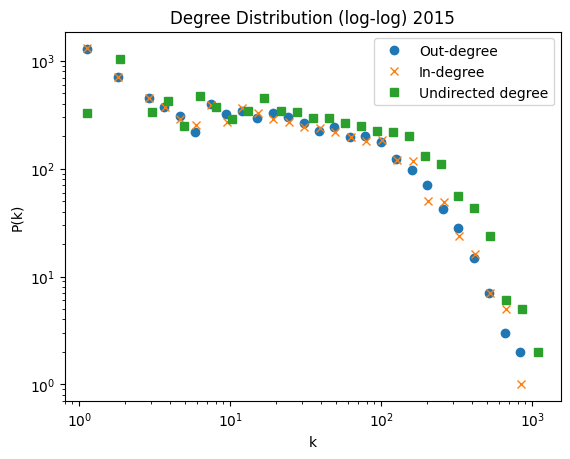

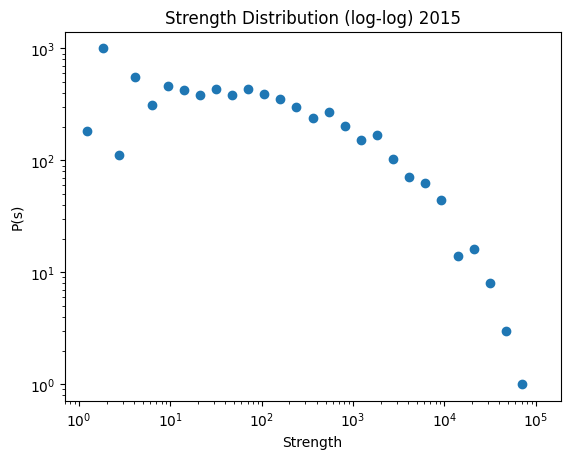

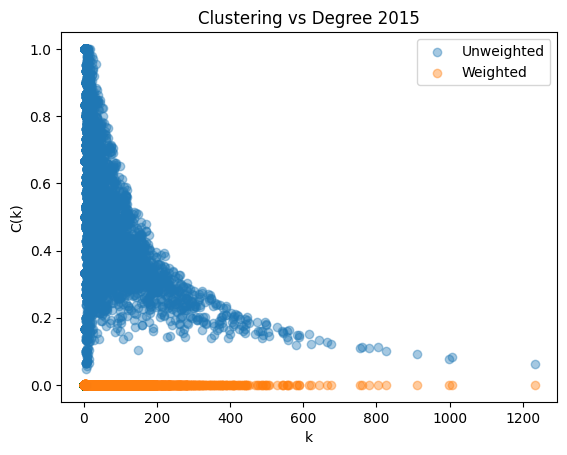

Avg clustering (unweighted): 0.5192966804634249
Avg clustering (weighted): 0.0001497030726479761


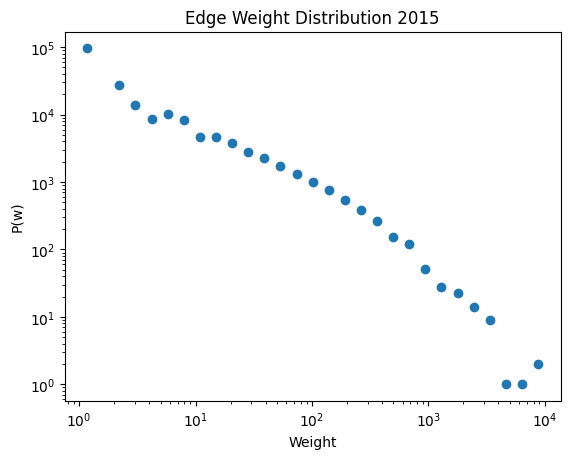

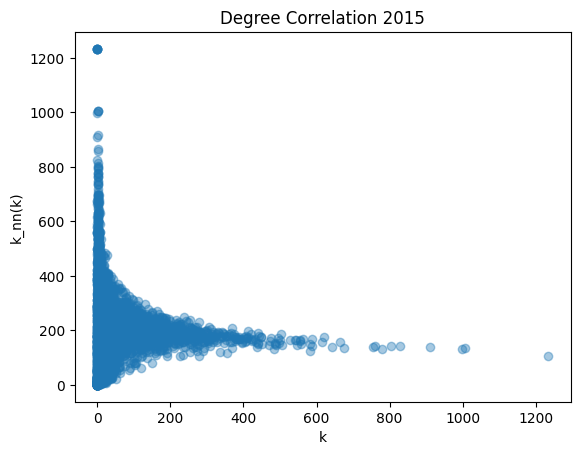

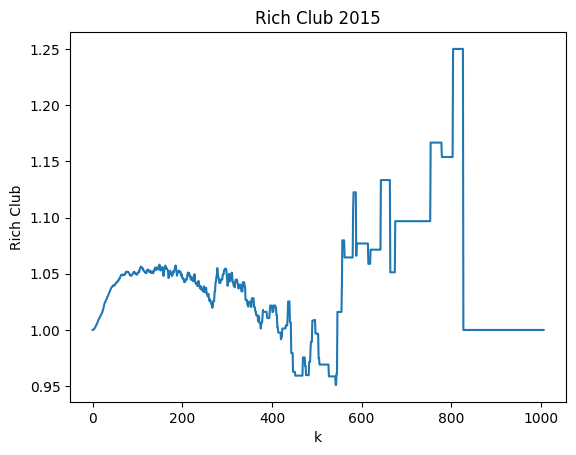

DIRECTED GRAPH
nodes: 7788
edges: 182300
density: 0.003006010900524355
SCCs: 274
WCCs: 76

UNDIRECTED GRAPH
nodes: 7788
edges: 139499
density: 0.004600499337490367
connected components: 76


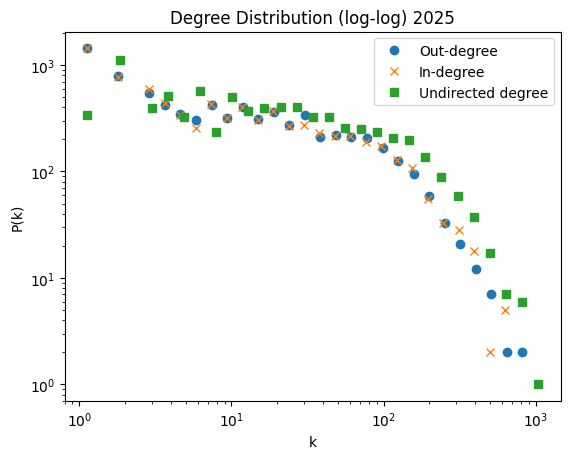

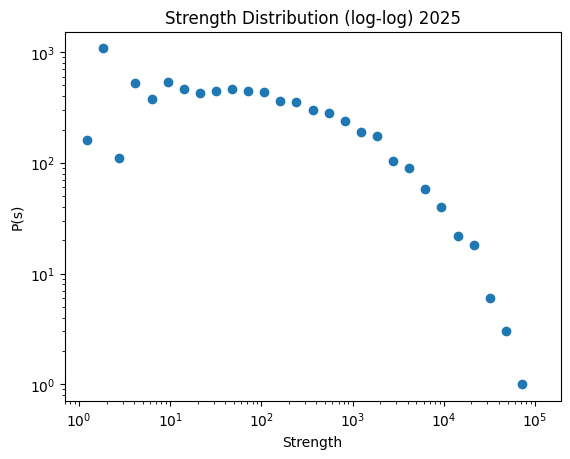

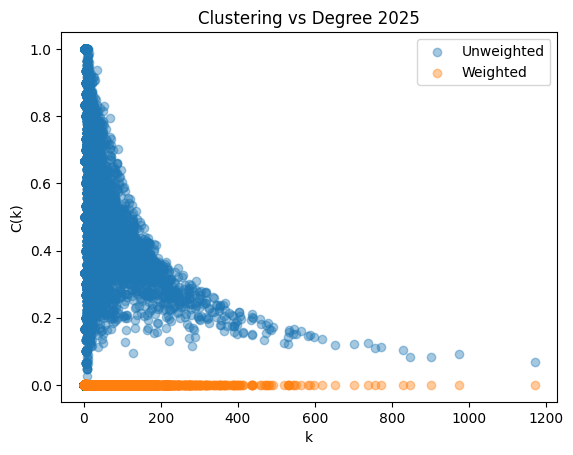

Avg clustering (unweighted): 0.4839500253487355
Avg clustering (weighted): 0.00011431756316809783


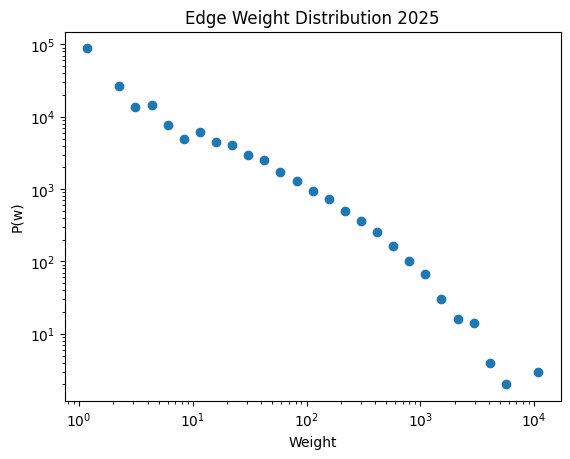

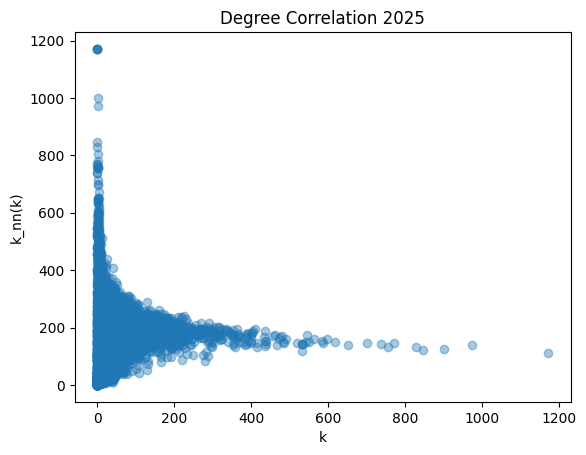

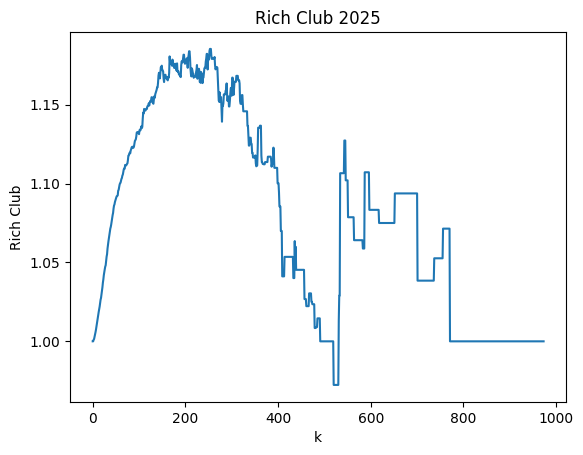

In [6]:
# ---- 2015 ----
ship_seq_2015 = build_ship_sequences(df_2015)
Gd_2015 = build_directed_weighted_graph(ship_seq_2015)
Gu_2015 = build_undirected_weighted_graph(Gd_2015)

attach_port_metadata(Gd_2015, df_2015)
attach_port_metadata(Gu_2015, df_2015)

graph_eda(Gd_2015, Gu_2015)
degree_distributions(Gd_2015, Gu_2015, label="2015")
clustering_metrics(Gd_2015, Gu_2015, label="2015")
# path_length_metrics(Gd_2015, Gu_2015, label="2015")

edge_weight_distribution(Gd_2015, "2015")
knn_plot(Gu_2015, "2015")
# betweenness_distribution(Gu_2015, "2015")
rich_club_plot(Gu_2015, "2015")


# ---- 2025 ----
ship_seq_2025 = build_ship_sequences(df_2025)
Gd_2025 = build_directed_weighted_graph(ship_seq_2025)
Gu_2025 = build_undirected_weighted_graph(Gd_2025)

attach_port_metadata(Gd_2025, df_2025)
attach_port_metadata(Gu_2025, df_2025)

graph_eda(Gd_2025, Gu_2025)
degree_distributions(Gd_2025, Gu_2025, label="2025")
clustering_metrics(Gd_2025, Gu_2025, label="2025")
# path_length_metrics(Gd_2025, Gu_2025, label="2025")

edge_weight_distribution(Gd_2025, "2025")
knn_plot(Gu_2025, "2025")
# betweenness_distribution(Gu_2025, "2025")
rich_club_plot(Gu_2025, "2025")

In [7]:
# =========================
# WEIGHTED NETWORK METRICS
# =========================

def weighted_network_metrics(Gd, Gu, label=""):
    print(f"\n===== WEIGHTED METRICS: {label} =====")

    # -------------------------
    # Assortativity (Directed)
    # -------------------------
    try:
        assort_in_in = nx.degree_assortativity_coefficient(Gd, x="in", y="in")
        assort_out_out = nx.degree_assortativity_coefficient(Gd, x="out", y="out")
    except Exception:
        assort_in_in, assort_out_out = np.nan, np.nan

    print("Assortativity (in-in):", assort_in_in)
    print("Assortativity (out-out):", assort_out_out)

    # -------------------------
    # Strength Distribution
    # -------------------------
    strengths = dict(Gu.degree(weight="weight"))
    strength_vals = np.array(list(strengths.values()))

    if len(strength_vals) > 0:
        x, y = log_binning(strength_vals)

        plt.figure()
        plt.loglog(x, y, 'o')
        plt.xlabel("Strength")
        plt.ylabel("P(s)")
        plt.title(f"Strength Distribution {label}")
        plt.show()

    mean_strength = np.mean(strength_vals) if len(strength_vals) else np.nan
    print("Mean Strength:", mean_strength)

    # -------------------------
    # Weighted Clustering: C(k) vs k
    # -------------------------
    c_w = nx.clustering(Gu, weight="weight")
    degree = dict(Gu.degree())
    
    # Prepare arrays
    c_d = {}
    
    for node in Gu.nodes():
        if degree[node] > 0:
            if degree[node] not in c_d: c_d[degree[node]] = []
            c_d[degree[node]].append(c_w[node])
    
    k_vals = np.array(sorted(c_d.keys()))
    c_vals = np.array([np.mean(c_d[k]) for k in k_vals])
    
    # -------------------------
    # Log-binning
    # -------------------------
    # bins = np.logspace(np.log10(k_vals.min()), np.log10(k_vals.max()), 20)
    
    # k_bin_centers = []
    # c_bin_means = []
    
    # for i in range(len(bins) - 1):
    #     mask = (k_vals >= bins[i]) & (k_vals < bins[i+1])
        
    #     if np.sum(mask) > 0:
    #         k_bin_centers.append(np.sqrt(bins[i] * bins[i+1]))  # geometric mean
    #         c_bin_means.append(np.mean(c_vals[mask]))
    
    # -------------------------
    # Plot
    # -------------------------
    plt.figure()
    
    # Binned curve (important)
    plt.loglog(k_vals, c_vals, 'o-', label="Log-binned")
    
    plt.xlabel("Degree k")
    plt.ylabel("C(k)")
    plt.title(f"Weighted Clustering C(k) vs k {label}")
    plt.legend()
    plt.show()
    
    print("Avg Weighted Clustering:", np.mean(c_vals))

    # Fit slope in log-log (optional)
    log_k = np.log10(k_vals)
    log_c = np.log10(c_vals)
    
    slope, intercept = np.polyfit(log_k, log_c, 1)
    print("Slope of C(k) ~ k^alpha:", slope)

    # -------------------------
    # Weighted Path Length
    # -------------------------
    # gcc = Gu.subgraph(max(nx.connected_components(Gu), key=len)).copy()
    # H = gcc.copy()

    # for u, v, data in H.edges(data=True):
    #     w = data.get("weight", 1)
    #     data["distance"] = 1.0 / w if w > 0 else np.inf

    # wapl = nx.average_shortest_path_length(H, weight="distance")
    # print("Weighted Avg Path Length:", wapl)

    # -------------------------
    # Betweenness (Weighted)
    # -------------------------
    # betw = nx.betweenness_centrality(Gu, weight="weight")
    # betw_vals = np.array(list(betw.values()))

    # x, y = log_binning(betw_vals + 1e-10)

    # plt.figure()
    # plt.loglog(x, y, 'o')
    # plt.xlabel("Betweenness")
    # plt.ylabel("P(b)")
    # plt.title(f"Betweenness Distribution {label}")
    # plt.show()

    # top_betw = sorted(betw.items(), key=lambda x: x[1], reverse=True)[:20]

    return {
        "assortativity_in_in": assort_in_in,
        "assortativity_out_out": assort_out_out,
        "mean_strength": mean_strength,
        "weighted_clustering": np.mean(c_vals),
        # "weighted_avg_path_length": wapl,
        # "betweenness_top20": top_betw,
    }

# =========================
# EDGE WEIGHT ANALYSIS
# =========================

def route_weight_summary(Gd, label=""):
    weights = np.array([data["weight"] for _, _, data in Gd.edges(data=True)])

    if len(weights) > 0:
        # Log-log distribution
        x, y = log_binning(weights)

        plt.figure()
        plt.loglog(x, y, 'o')
        plt.xlabel("Edge Weight")
        plt.ylabel("P(w)")
        plt.title(f"Edge Weight Distribution {label}")
        plt.show()

        # Normal histogram
        plt.figure()
        plt.hist(weights, bins=50)
        plt.xlabel("Weight")
        plt.ylabel("Frequency")
        plt.title(f"Edge Weight Histogram {label}")
        plt.show()

    return {
        "num_edges": len(weights),
        "min_weight": float(weights.min()) if len(weights) else np.nan,
        "max_weight": float(weights.max()) if len(weights) else np.nan,
        "mean_weight": float(weights.mean()) if len(weights) else np.nan,
        "median_weight": float(np.median(weights)) if len(weights) else np.nan,
    }

# =========================
# TOP PORTS ANALYSIS
# =========================

def top_ports_by_degree_and_strength(Gd, Gu, k=20, label=""):
    out_deg = dict(Gd.out_degree())
    in_deg = dict(Gd.in_degree())
    strength = dict(Gu.degree(weight="weight"))

    top_out = sorted(out_deg.items(), key=lambda x: x[1], reverse=True)[:k]
    top_in = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:k]
    top_str = sorted(strength.items(), key=lambda x: x[1], reverse=True)[:k]

    # Plot top-k comparison
    plt.figure()
    plt.plot([v for _, v in top_out], label="Out-degree")
    plt.plot([v for _, v in top_in], label="In-degree")
    plt.plot([v for _, v in top_str], label="Strength")
    plt.xlabel("Top Ports Rank")
    plt.ylabel("Value")
    plt.title(f"Top Ports Comparison {label}")
    plt.legend()
    plt.show()

    return {
        "top_out_degree": top_out,
        "top_in_degree": top_in,
        "top_strength": top_str
    }


===== 2015 ANALYSIS =====

===== WEIGHTED METRICS: 2015 =====
Assortativity (in-in): -0.05417626912136682
Assortativity (out-out): -0.0557408945549625


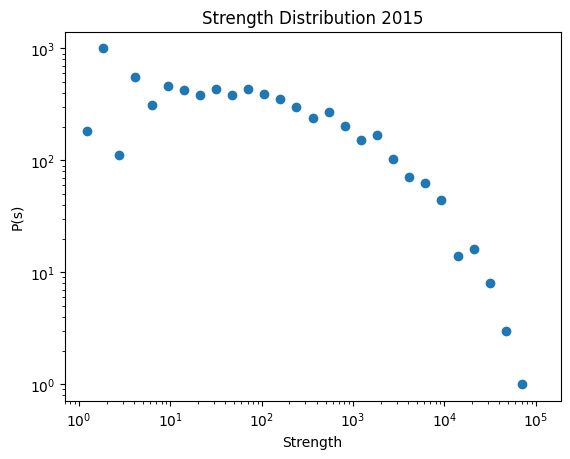

Mean Strength: 502.04398991314093


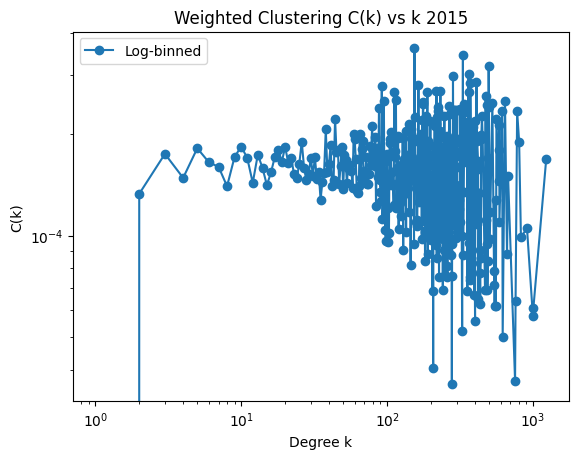

Avg Weighted Clustering: 0.00015506215992010954
Slope of C(k) ~ k^alpha: nan


/tmp/ipykernel_55/4212948616.py:89: RuntimeWarning: divide by zero encountered in log10
  log_c = np.log10(c_vals)


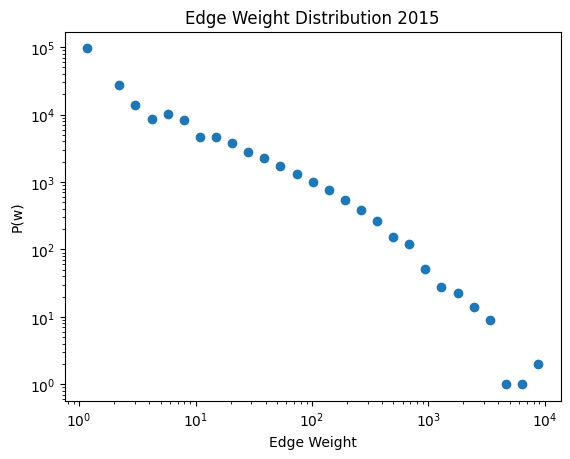

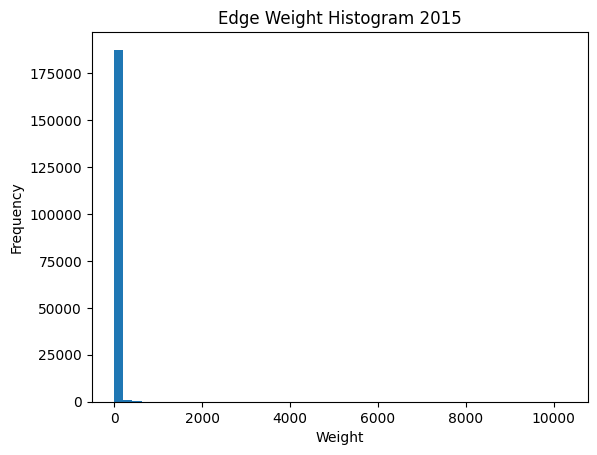

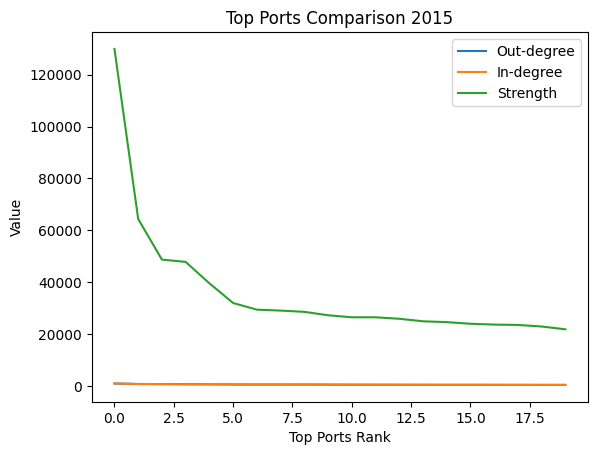


===== 2025 ANALYSIS =====

===== WEIGHTED METRICS: 2025 =====
Assortativity (in-in): 0.0023602354853693593
Assortativity (out-out): -0.005308737604076883


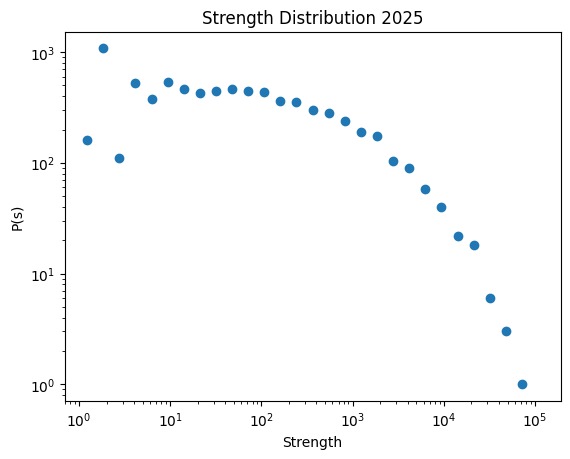

Mean Strength: 504.705957883924


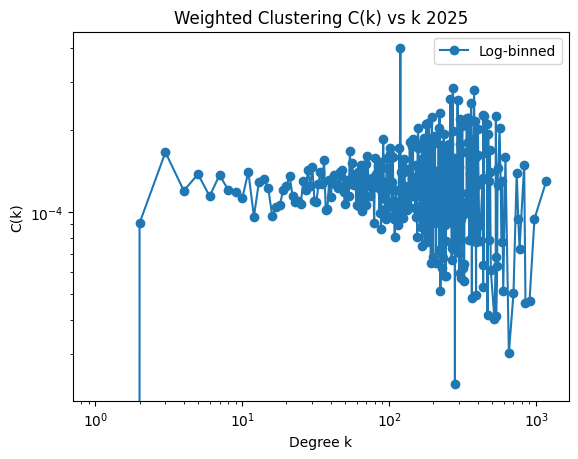

Avg Weighted Clustering: 0.00012451155373430702
Slope of C(k) ~ k^alpha: nan


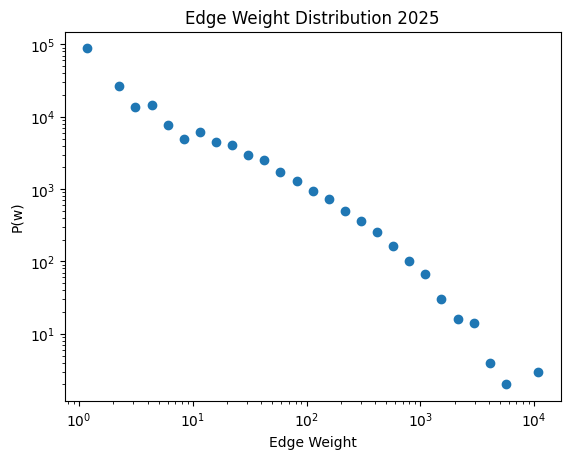

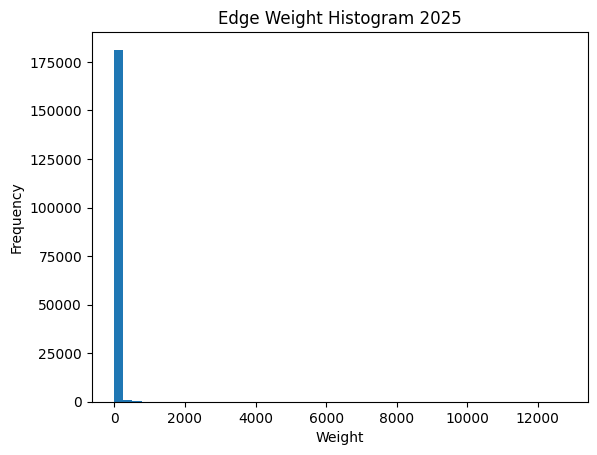

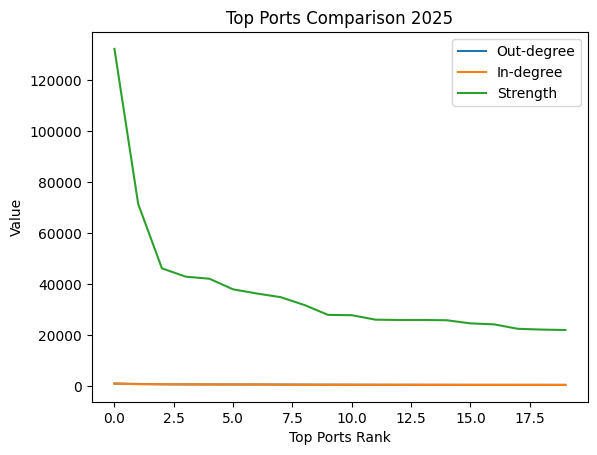

{'top_out_degree': [('chn-shanghai', 921),
  ('mys-telokramunia', 765),
  ('bel-antwerp', 636),
  ('nld-rotterdammaasvlakte', 579),
  ('chn-ningbo', 572),
  ('sgp-singapore', 552),
  ('chn-guangzhou', 543),
  ('gib-gibraltar', 528),
  ('chn-hongkong', 516),
  ('dnk-skagen', 483),
  ('chn-shenzhen', 473),
  ('esp-laspalmas', 451),
  ('tur-istanbul', 442),
  ('kor-yeosu', 437),
  ('chn-zhoushan', 427),
  ('chn-caofeidian', 415),
  ('kor-busan', 415),
  ('mys-portklang', 411),
  ('mlt-marsaxlokk', 410),
  ('swe-goteborg', 394)],
 'top_in_degree': [('chn-shanghai', 899),
  ('bel-antwerp', 675),
  ('chn-ningbo', 664),
  ('nld-rotterdammaasvlakte', 626),
  ('chn-guangzhou', 568),
  ('mys-telokramunia', 567),
  ('chn-hongkong', 552),
  ('gib-gibraltar', 490),
  ('nld-rotterdam', 442),
  ('jpn-yokohama', 439),
  ('dnk-skagen', 437),
  ('chn-shenzhen', 431),
  ('kor-yeosu', 430),
  ('sgp-singapore', 413),
  ('chn-caofeidian', 407),
  ('esp-laspalmas', 402),
  ('mys-portklang', 401),
  ('mlt-mar

In [8]:
# =========================
# FINAL METRICS CALLS
# =========================

print("\n===== 2015 ANALYSIS =====")
weighted_network_metrics(Gd_2015, Gu_2015, "2015")
route_weight_summary(Gd_2015, "2015")
top_ports_by_degree_and_strength(Gd_2015, Gu_2015, label="2015")


print("\n===== 2025 ANALYSIS =====")
weighted_network_metrics(Gd_2025, Gu_2025, "2025")
route_weight_summary(Gd_2025, "2025")
top_ports_by_degree_and_strength(Gd_2025, Gu_2025, label="2025")